In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data = pd.read_csv("C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/Projeto Dados Comportamentais TSE/Dados RJ Eleitores/Dados RJ Eleitores/perfil_comparecimento_abstencao_2022_RJ.csv", encoding="latin1", sep=";")

In [9]:
data.head(5)

,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,NR_TURNO,SG_UF,CD_MUNICIPIO,NM_MUNICIPIO,NR_ZONA,CD_GENERO,DS_GENERO,...,QT_COMPARECIMENTO_TTE,QT_ABSTENCAO_TTE,QT_COMPAREC_FACULTATIVO,QT_ABST_FACULTATIVO,QT_COMPAREC_OBRIGATORIO,QT_ABST_OBRIGATORIO,QT_COMPAREC_DEFIC_FACULTATIVO,QT_ABST_DEFIC_FACULTATIVO,QT_COMPAREC_DEFIC_OBRIGATORIO,QT_ABST_DEFIC_OBRIGATORIO
0,29/04/2025,22:31:40,2022,1,RJ,58009,QUISSAMÃ,255,2,MASCULINO,...,0,0,0,2,0,0,0,0,0,0
1,29/04/2025,22:31:40,2022,1,RJ,58009,QUISSAMÃ,255,2,MASCULINO,...,0,0,6,5,0,0,0,1,0,0
2,29/04/2025,22:31:40,2022,1,RJ,58009,QUISSAMÃ,255,2,MASCULINO,...,0,0,1,0,0,0,0,0,0,0
3,29/04/2025,22:31:40,2022,1,RJ,58009,QUISSAMÃ,255,2,MASCULINO,...,0,0,15,17,0,0,1,0,0,0
4,29/04/2025,22:31:40,2022,1,RJ,58009,QUISSAMÃ,255,2,MASCULINO,...,0,0,56,24,0,0,1,1,0,0


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411504 entries, 0 to 411503
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   DT_GERACAO                     411504 non-null  object
 1   HH_GERACAO                     411504 non-null  object
 2   ANO_ELEICAO                    411504 non-null  int64 
 3   NR_TURNO                       411504 non-null  int64 
 4   SG_UF                          411504 non-null  object
 5   CD_MUNICIPIO                   411504 non-null  int64 
 6   NM_MUNICIPIO                   411504 non-null  object
 7   NR_ZONA                        411504 non-null  int64 
 8   CD_GENERO                      411504 non-null  int64 
 9   DS_GENERO                      411504 non-null  object
 10  CD_ESTADO_CIVIL                411504 non-null  int64 
 11  DS_ESTADO_CIVIL                411504 non-null  object
 12  CD_FAIXA_ETARIA                411504 non-nu

In [11]:
data['DT_GERACAO'] = pd.to_datetime(data['DT_GERACAO'], dayfirst=True, errors='coerce')
data['HH_GERACAO'] = pd.to_datetime(data['HH_GERACAO'], dayfirst=True, errors='coerce')

In [12]:
data['ANO_ELEICAO'] = data['ANO_ELEICAO'].astype(int)
data['ANO_ELEICAO'] = pd.to_datetime(data['ANO_ELEICAO'], format='%Y')

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411504 entries, 0 to 411503
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   DT_GERACAO                     411504 non-null  datetime64[ns]
 1   HH_GERACAO                     411504 non-null  datetime64[ns]
 2   ANO_ELEICAO                    411504 non-null  datetime64[ns]
 3   NR_TURNO                       411504 non-null  int64         
 4   SG_UF                          411504 non-null  object        
 5   CD_MUNICIPIO                   411504 non-null  int64         
 6   NM_MUNICIPIO                   411504 non-null  object        
 7   NR_ZONA                        411504 non-null  int64         
 8   CD_GENERO                      411504 non-null  int64         
 9   DS_GENERO                      411504 non-null  object        
 10  CD_ESTADO_CIVIL                411504 non-null  int64         
 11  

In [14]:
comparecimento_X_abstencao = data.groupby('ANO_ELEICAO')[['QT_COMPARECIMENTO', 'QT_ABSTENCAO', 'QT_COMPARECIMENTO_DEFICIENCIA', 'QT_ABSTENCAO_DEFICIENCIA']].sum().reset_index()
comparecimento_X_abstencao.head()

,ANO_ELEICAO,QT_COMPARECIMENTO,QT_ABSTENCAO,QT_COMPARECIMENTO_DEFICIENCIA,QT_ABSTENCAO_DEFICIENCIA
0,2022-01-01,19883682,5770910,108919,64393


In [ ]:
qt_comparecimento = data['QT_COMPARECIMENTO'].sum()
qt_abstencao = data['QT_ABSTENCAO'].sum()

total_eleitores =  + qt_abstencao

porcentagem_comparecimento = (qt_comparecimento / total_eleitores) * 100
porcentagem_abstencao = (qt_abstencao / total_eleitores) * 100

print(f"Total de eleitores: {total_eleitores:,}")
print(f"Comparecimento: {qt_comparecimento:,} ({porcentagem_comparecimento:.2f}%)")
print(f"Abstenção: {qt_abstencao:,} ({porcentagem_abstencao:.2f}%)")

Total de eleitores: 25,654,592
Comparecimento: 19,883,682 (77.51%)
Abstenção: 5,770,910 (22.49%)


In [15]:
masculino_X_feminino = data.groupby('DS_GENERO')[['QT_COMPARECIMENTO', 'QT_ABSTENCAO', 'QT_COMPARECIMENTO_DEFICIENCIA', 'QT_ABSTENCAO_DEFICIENCIA']].sum().reset_index()
masculino_X_feminino.sort_values(by='QT_COMPARECIMENTO', ascending=False).head()

,DS_GENERO,QT_COMPARECIMENTO,QT_ABSTENCAO,QT_COMPARECIMENTO_DEFICIENCIA,QT_ABSTENCAO_DEFICIENCIA
0,FEMININO,10788529,3044929,57552,36816
1,MASCULINO,9084548,2715900,51361,27555
2,NÃO INFORMADO,10605,10081,6,22


In [16]:
grau_escolaridade = data.groupby('DS_GRAU_ESCOLARIDADE')[['QT_COMPARECIMENTO', 'QT_ABSTENCAO', 'QT_COMPARECIMENTO_DEFICIENCIA', 'QT_ABSTENCAO_DEFICIENCIA']].sum().reset_index()
grau_escolaridade.sort_values(by='QT_COMPARECIMENTO', ascending=False).head()

,DS_GRAU_ESCOLARIDADE,QT_COMPARECIMENTO,QT_ABSTENCAO,QT_COMPARECIMENTO_DEFICIENCIA,QT_ABSTENCAO_DEFICIENCIA
3,ENSINO MÉDIO COMPLETO,5010821,1019233,25865,9885
4,ENSINO MÉDIO INCOMPLETO,4668742,1017290,11937,3825
2,ENSINO FUNDAMENTAL INCOMPLETO,4608512,1563102,26261,17027
7,SUPERIOR COMPLETO,1934671,372179,16414,4910
1,ENSINO FUNDAMENTAL COMPLETO,1564969,580685,10713,6695


In [17]:
comparecimento_X_abstencao = data.groupby('DS_ESTADO_CIVIL')[['QT_COMPARECIMENTO', 'QT_ABSTENCAO', 'QT_COMPARECIMENTO_DEFICIENCIA', 'QT_ABSTENCAO_DEFICIENCIA']].sum().reset_index()
comparecimento_X_abstencao.sort_values(by='QT_COMPARECIMENTO', ascending=False).head()

,DS_ESTADO_CIVIL,QT_COMPARECIMENTO,QT_ABSTENCAO,QT_COMPARECIMENTO_DEFICIENCIA,QT_ABSTENCAO_DEFICIENCIA
4,SOLTEIRO,13222120,3277958,52678,28570
0,CASADO,5483882,1931812,37798,20882
1,DIVORCIADO,688505,178293,8880,4592
5,VIÚVO,307572,281288,7861,9133
3,SEPARADO JUDICIALMENTE,165113,87177,1684,1164


In [18]:
municipios = data.groupby('NM_MUNICIPIO')[['QT_COMPARECIMENTO', 'QT_ABSTENCAO', 'QT_COMPARECIMENTO_DEFICIENCIA', 'QT_ABSTENCAO_DEFICIENCIA']].sum().reset_index()
municipios.sort_values(by='QT_COMPARECIMENTO', ascending=False).head(10)

,NM_MUNICIPIO,QT_COMPARECIMENTO,QT_ABSTENCAO,QT_COMPARECIMENTO_DEFICIENCIA,QT_ABSTENCAO_DEFICIENCIA
67,RIO DE JANEIRO,7628420,2376822,41871,23263
24,DUQUE DE CAXIAS,1066015,278227,9207,4963
77,SÃO GONÇALO,1042994,298294,3840,2224
49,NOVA IGUAÇU,969354,254312,2628,1328
47,NITERÓI,657571,153259,10851,7943
81,SÃO JOÃO DE MERITI,583351,171459,7587,4325
14,CAMPOS DOS GOYTACAZES,572049,166887,1920,1170
8,BELFORD ROXO,531099,146329,1973,1147
54,PETRÓPOLIS,372162,115376,1148,674
91,VOLTA REDONDA,359213,92385,1964,962


In [19]:
total_QT_COMPARECIMENTO = data['QT_COMPARECIMENTO'].sum()
print(f"O Total de comparecimento foi de: {total_QT_COMPARECIMENTO}")

O Total de comparecimento foi de: 19883682


In [20]:
total_QT_ABSTENCAO = data['QT_ABSTENCAO'].sum()
print(f'O Total de abstenção foi de: {total_QT_ABSTENCAO}')

O Total de abstenção foi de: 5770910


In [21]:
municipios.sort_values(by='QT_COMPARECIMENTO', ascending=True).head(10)

,NM_MUNICIPIO,QT_COMPARECIMENTO,QT_ABSTENCAO,QT_COMPARECIMENTO_DEFICIENCIA,QT_ABSTENCAO_DEFICIENCIA
35,LAJE DO MURIAÉ,11420,3368,49,45
37,MACUCO,11663,2643,50,48
78,SÃO JOSÉ DE UBÁ,11949,2779,44,20
83,SÃO SEBASTIÃO DO ALTO,12516,3014,72,56
65,RIO DAS FLORES,13392,3832,31,13
20,COMENDADOR LEVY GASPARIAN,13548,2652,49,25
89,VARRE-SAI,13781,3553,146,126
68,SANTA MARIA MADALENA,14060,4028,79,97
86,TRAJANO DE MORAES,14332,3182,54,40
3,AREAL,15867,3781,32,32


In [22]:
faixa_etaria = data.groupby('DS_FAIXA_ETARIA')[['QT_COMPARECIMENTO', 'QT_ABSTENCAO']].sum().reset_index()
faixa_etaria.sort_values(by='QT_COMPARECIMENTO', ascending=False).head(30)

,DS_FAIXA_ETARIA,QT_COMPARECIMENTO,QT_ABSTENCAO
10,40 a 44 anos,2110697,399563
9,35 a 39 anos,1944599,414753
7,25 a 29 anos,1927031,502547
11,45 a 49 anos,1886677,323385
8,30 a 34 anos,1864272,449874
13,55 a 59 anos,1814287,253283
12,50 a 54 anos,1805388,272872
14,60 a 64 anos,1614014,229280
6,21 a 24 anos,1458541,377557
15,65 a 69 anos,1301426,232550


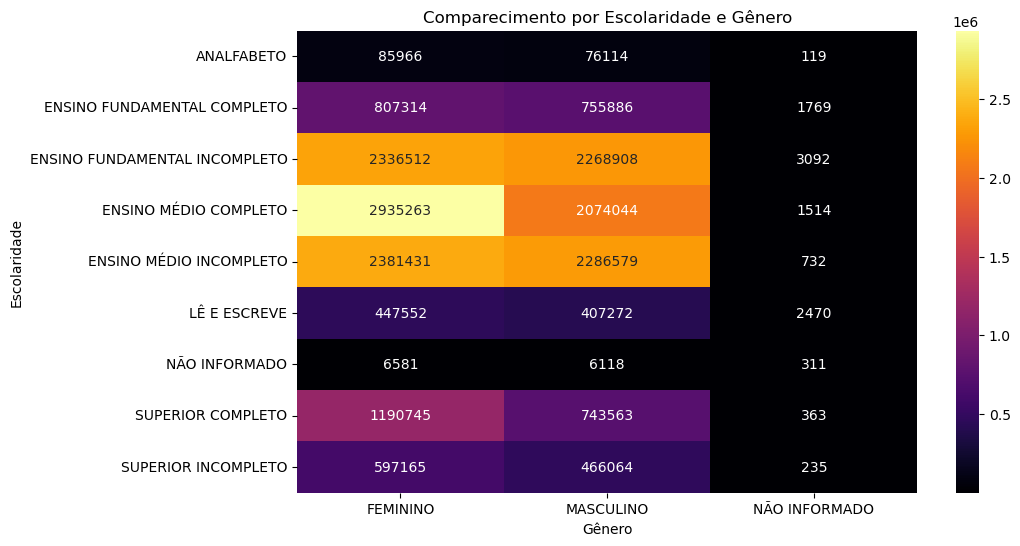

In [23]:
grafico1 = data.pivot_table(
    index='DS_GRAU_ESCOLARIDADE', 
    columns='DS_GENERO', 
    values='QT_COMPARECIMENTO', 
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
sns.heatmap(grafico1, annot=True, fmt=".0f", cmap="inferno")
plt.title('Comparecimento por Escolaridade e Gênero')
plt.ylabel('Escolaridade')
plt.xlabel('Gênero')
plt.show()

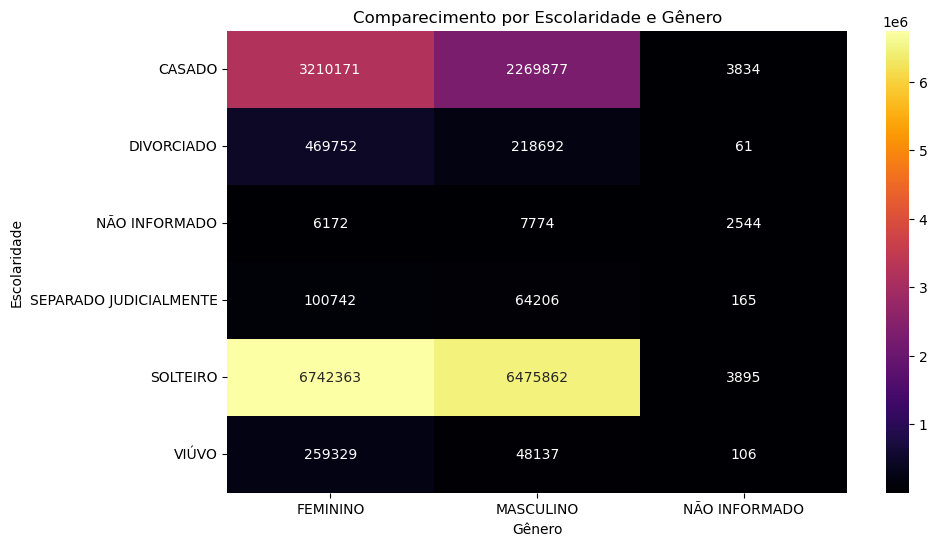

In [32]:
grafico2 = data.pivot_table(
    index='DS_ESTADO_CIVIL',
    columns='DS_GENERO', 
    values='QT_COMPARECIMENTO', 
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
sns.heatmap(grafico2, annot=True, fmt=".0f", cmap="inferno")
plt.title('Comparecimento por Escolaridade e Gênero')
plt.ylabel('Escolaridade')
plt.xlabel('Gênero')
plt.show()

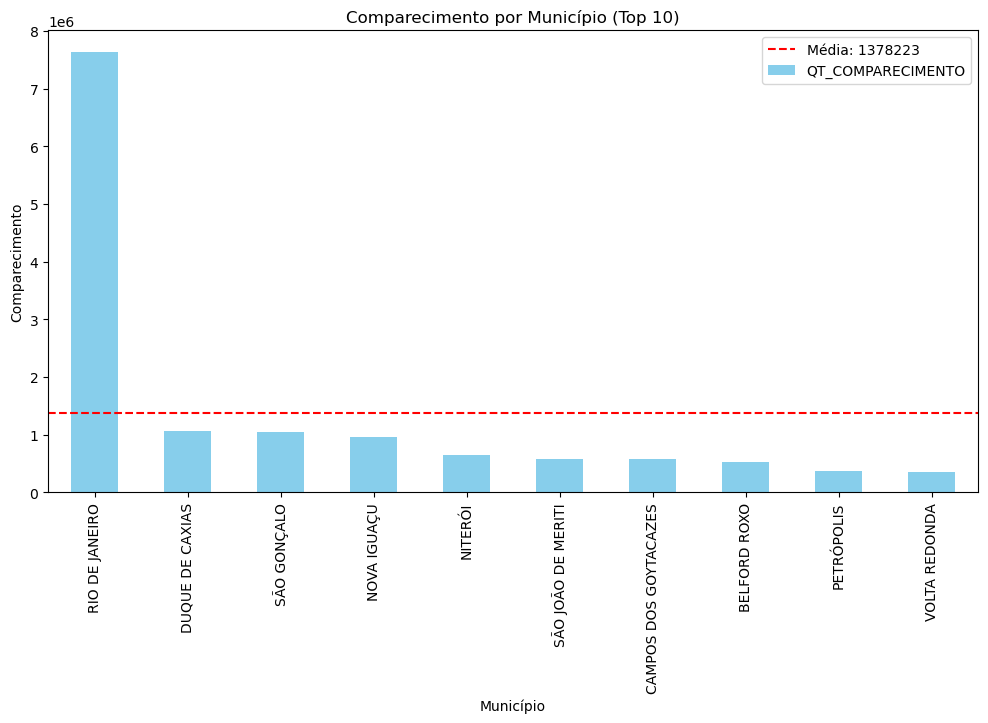

In [24]:
top_municipios_compareceu = data.groupby('NM_MUNICIPIO')['QT_COMPARECIMENTO'].sum().sort_values(ascending=False).head(10)

media = top_municipios_compareceu.mean()

plt.figure(figsize=(12,6))
top_municipios_compareceu.plot(kind='bar', color='skyblue')
plt.axhline(media, color='red', linestyle='--', label=f'Média: {media:.0f}')
plt.title('Comparecimento por Município (Top 10)')
plt.ylabel('Comparecimento')
plt.xlabel('Município')
plt.legend()
plt.show()

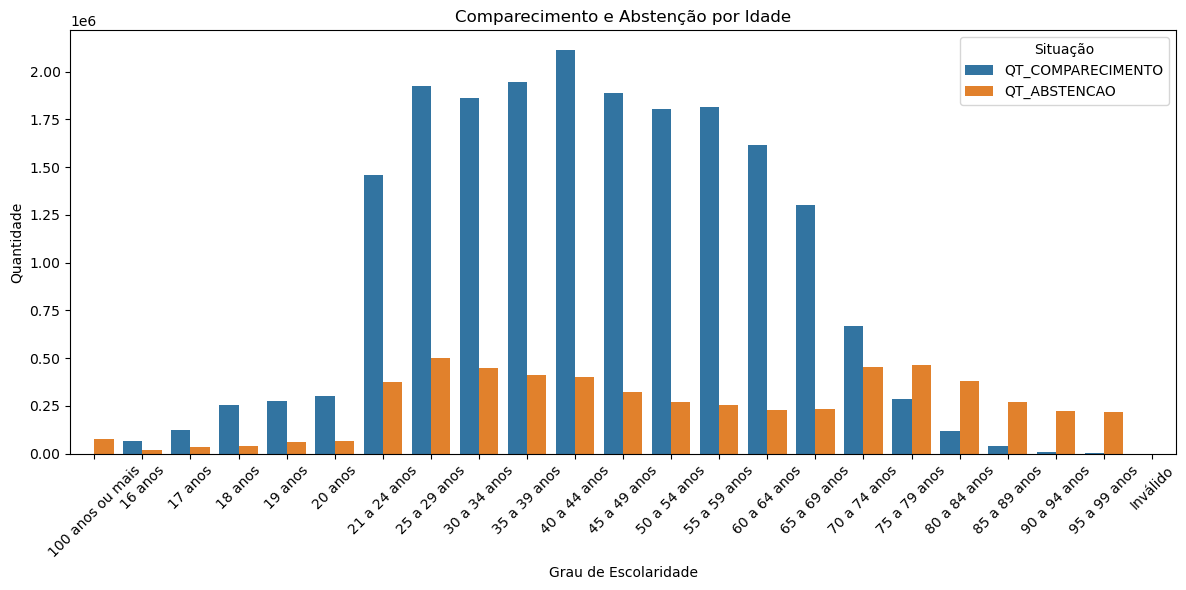

In [26]:
grafico3 = faixa_etaria.melt(id_vars='DS_FAIXA_ETARIA', 
                       value_vars=['QT_COMPARECIMENTO', 'QT_ABSTENCAO'],
                       var_name='Situação', value_name='Quantidade')

plt.figure(figsize=(12,6))
sns.barplot(data=grafico3, x='DS_FAIXA_ETARIA', y='Quantidade', hue='Situação')
plt.title('Comparecimento e Abstenção por Idade')
plt.xlabel('Grau de Escolaridade')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.legend(title='Situação')
plt.tight_layout()
plt.show()